In [42]:
import duckdb
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt



con = duckdb.connect('../capillary.db')

df = con.execute("""
                SELECT id,
                    any_value(pid) as pid, 
                    any_value(value) as value,
                    any_value(analysis) as analysis,
                    any_value(protein_value) as protein_value,
                    list(c.comment_nr) as comment_nr,
                    any_value(sign) as sign
                FROM protein_data p
                LEFT JOIN comment_precences c 
                    ON p.id = c.row_id
                GROUP BY id
                 """).df()

pids = con.execute("SELECT DISTINCT pid FROM protein_data").df()

con.close()

def to_severity(comments: list[int]):
    max_found = 0
    for comment in comments:
        result = map_severity(comment)
        if result > max_found:
            max_found = result
    return max_found
        

def map_severity(label: int) -> int:        
    severity = 0
    match label:
        case 8:
            severity = 1 #Hypoalbuminemi
        case 9:
            severity = 2 #Påtaglig hypoalbuminemi
        case 10:
            severity = 3 #Grav hypoalbuminemi
        case _:
            severity = 0
    return severity

def to_coral(label: int, num_classes: int = 4):
    severity = to_severity(label)
    new_label = []
    for i in range(num_classes-1):
        if severity > i:
            new_label.append(1)
        else:
            new_label.append(0)
    return new_label

def extract_relevant_values(analysis_list: list[str], value_list: list[str], relevant: list[str]) -> np.array:
    protein_values = np.array([np.nan]*len(relevant))
    mapping = dict()

    if len(analysis_list) > len(value_list):
        raise Exception("Analysis list and value list must be of same length!")
    
    for i in range(len(analysis_list)):
        analysis = analysis_list[i].replace('*','')
        value = clean_value(value_list[i])
        mapping.update({analysis: value})

    for (i, analysis) in enumerate(relevant):
        protein_values[i] = mapping.get(analysis,np.nan)

    #får vi en nan får vi tyvärr hoppa över hela raden, jag kör pd.dropna senare
    if sum( (np.isnan(protein_values) == True) ) > 0:
        return np.nan

    return protein_values


def clean_value(val: str) -> float:
    if val is None or val == '' or val == 'NA' or val == 'NEG':
        return np.nan
    try:
        return float(str(val).replace('<', '').replace('>', '').strip())
    except:
        return np.nan
    


    
#hämta ut protein-value
relevant_anlysis = ['0054','0055','0056','0058','0062','0064','0065','0066']
df['protein_value'] = df.apply(
    lambda row: extract_relevant_values(
        row['analysis'], 
        row['protein_value'], 
        relevant_anlysis
    ), 
    axis=1
)


df = df[df['value'].apply(len) == 301]
df['value'] = df['value'].apply(lambda x: x[:300])

df['label'] = df['comment_nr'].apply(to_coral)
df['severity'] = df['comment_nr'].apply(to_severity)
df = df.dropna()
df = df.set_index('id')




FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [43]:
severity_range = [0,1,2,3]

most_frequent = 0
position_weights = []

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    print(f"Antal fall med klass {i}:{no_occurences}")
    if no_occurences > most_frequent:
        most_frequent=no_occurences

for i in severity_range:
    no_occurences = (df['severity'] == i).sum()
    position_weights.append( most_frequent/no_occurences) 

df['albumin'] = df['protein_value'].apply(lambda x: x[0])
df['frisk'] = df['label'].apply(lambda x: x[0] == 0)


df['hypoalmbuminemi'] = (df['severity'] == 1).astype(int)
df['påtaglig_hypoalbuminemi'] = (df['severity'] == 2).astype(int)
df['grav_hypoalbuminemi'] = (df['severity'] == 3).astype(int)
df


Antal fall med klass 0:141988
Antal fall med klass 1:7928
Antal fall med klass 2:5165
Antal fall med klass 3:1967


,pid,value,analysis,protein_value,comment_nr,sign,label,severity,albumin,frisk,hypoalmbuminemi,påtaglig_hypoalbuminemi,grav_hypoalbuminemi
id,,,,,,,,,,,,,
122896,11327434,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 2, 2, 2, 2, 3, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[47.0, 0.5, 1.4, 1.06, 0.43, 11.8, 1.9, 0.77]","[97, 69, 68, 66, 20, 4]",200557,"[0, 0, 0]",0,47.0,True,0,0,0
122898,98559506,"[0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[51.0, 0.89, 0.88, 0.71, 1.1, 10.7, 0.92, 1.81]","[802, 68, 820, 97, 69, 66, 20, 4]",nxu,"[0, 0, 0]",0,51.0,True,0,0,0
122998,93309029,"[0, 1, 2, 2, 2, 3, 4, 4, 4, 5, 5, 5, 5, 5, 5, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[24.0, 0.36, 2.0, 0.49, 21.0, 19.4, 9.44, 2.85]","[8, 97, 70, 22, 9]",av,"[1, 1, 0]",2,24.0,False,0,1,0
123045,22112050,"[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 2, 2, 2, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[51.0, 0.58, 1.2, 0.53, 0.3, 12.6, 1.23, 0.95]","[66, 20, 97, 67]",pad,"[0, 0, 0]",0,51.0,True,0,0,0
123337,28836092,"[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[45.0, 0.53, 1.89, 0.92, 0.3, 11.3, 2.53, 1.7]","[66, 68, 97, 69, 20, 4]",av,"[0, 0, 0]",0,45.0,True,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
122545,41001948,"[0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[40.0, 0.96, 1.73, 2.39, 1.8, 7.49, 4.42, 0.51]","[107, 18, 66]",pad,"[0, 0, 0]",0,40.0,True,0,0,0
122593,28881078,"[0, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, ...","[0054, 0056, 0055, 0058, 0062, 0064, 0065, 006...","[39.0, 1.53, 2.01, 3.2, 31.0, 13.7, 5.44, 1.18]","[70, 97, 24]",mla,"[0, 0, 0]",0,39.0,True,0,0,0
122647,82792093,"[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 2, ...","[0054, 0056, 0055, 0058, 0062, *0064, 0065, 00...","[43.0, 0.9, 1.61, 1.97, 1.8, 10.5, 3.64, 1.23]","[18, 90]",oro,"[0, 0, 0]",0,43.0,True,0,0,0


In [44]:
valtrain_pids, test_pids = train_test_split(pids, test_size=0.15,random_state=25)
train_pids, val_pids = train_test_split(valtrain_pids, test_size=0.15,random_state=25)

train_set = set(train_pids['pid'])
val_set = set(val_pids['pid'])
print(len(train_set & val_set))  # ska vara 0


test_rows = df[ df['pid'].isin(test_pids['pid'].tolist()) ]
val_rows = df[ df['pid'].isin(val_pids['pid'].tolist()) ]
train_rows = df[ df['pid'].isin(train_pids['pid'].tolist()) ]

print(f"Antal fall med albuminavvikelse i träningsdatan:{(train_rows['severity'] != 0).sum()}")
print(f"Antal fall utan albuminavvikelse i träningsdatan:{(train_rows['severity'] == 0).sum()}")
print(f"Antal fall med albuminavvikelse i testdatan:{(test_rows['severity'] != 0).sum()}")
print(f"Antal fall utan albuminavvikelse i testdatan:{(test_rows['severity'] == 0).sum()}")


0
Antal fall med albuminavvikelse i träningsdatan:10926
Antal fall utan albuminavvikelse i träningsdatan:101935
Antal fall med albuminavvikelse i testdatan:2415
Antal fall utan albuminavvikelse i testdatan:21717


(array([   4.,    2.,    3.,   13.,   36.,   24.,   26.,   33.,   51.,
          52.,   61.,   84.,  126.,  163., 1212.,  974., 1391., 1182.,
         305.]),
 array([15.        , 16.05263158, 17.10526316, 18.15789474, 19.21052632,
        20.26315789, 21.31578947, 22.36842105, 23.42105263, 24.47368421,
        25.52631579, 26.57894737, 27.63157895, 28.68421053, 29.73684211,
        30.78947368, 31.84210526, 32.89473684, 33.94736842, 35.        ]),
 <BarContainer object of 19 artists>)

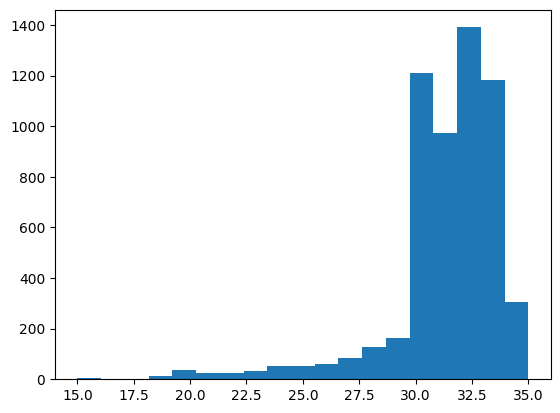

In [58]:
plt.figure()
bins = np.linspace(15,35,20)
plt.hist(train_rows[train_rows['severity'] == 1]['albumin'],bins=bins)

## Resultat: 

hypoalbuminemi: <34 \
påtaglig hypoalbuminemi: < 30 \
grav hypoalbuminemi: <24